# 체형·목적 기반 AI 코디 추천

입력 검증 → 체형 분석 → 의류 분리 → DeepFashion 라벨 체계 기반 착장 분석 → 코디 추천 → 결과 저장 순서로 실행합니다.

## 0. 팀원별 로컬 경로 설정 — 먼저 이 셀만 수정하세요

절대경로와 프로젝트 폴더 기준 상대경로를 모두 사용할 수 있습니다. 빈 데이터·출력 경로는 프로젝트 내부 기본 폴더를 사용합니다.

In [29]:
from pathlib import Path
import json
import os
import sys

from IPython.display import display
from PIL import Image

# ======================================================================
# [팀원별 로컬 설정] 이 값들만 본인의 환경에 맞게 수정하세요.
PROJECT_DIR_INPUT = r''                 # 비워두면 현재 폴더에서 자동 탐색
IMAGE_PATH_INPUT = r'data/input_person6.jpg'  # 분석할 전신사진
DATA_DIR_INPUT = r''                    # 비워두면 PROJECT_DIR/data
OUTPUT_DIR_INPUT = r''                  # 비워두면 PROJECT_DIR/outputs
FONT_PATH_INPUT = r''                   # 선택: 한글 TTF/TTC 글꼴
RULES_PATH_INPUT = r'FASHION_RULES_MASTER.md'
ATTRIBUTE_HEADS_PATH_INPUT = r'models/fashion_attribute_heads_augmented.pt'
LAYERING_HEADS_PATH_INPUT = r'models/layering_heads.pt'
# ======================================================================

def resolve_local_path(value, default, base_dir):
    selected = Path(value).expanduser() if value else Path(default)
    if not selected.is_absolute():
        selected = Path(base_dir) / selected
    return selected.resolve()

if PROJECT_DIR_INPUT:
    PROJECT_DIR = Path(PROJECT_DIR_INPUT).expanduser().resolve()
else:
    candidates = [Path.cwd(), Path.cwd() / 'ai_fashion_recommender']
    PROJECT_DIR = next((p.resolve() for p in candidates if (p / 'src' / 'config.py').exists()), None)
if PROJECT_DIR is None or not (PROJECT_DIR / 'src' / 'config.py').is_file():
    raise FileNotFoundError('PROJECT_DIR_INPUT에 올바른 프로젝트 폴더를 입력하세요.')

IMAGE_PATH = resolve_local_path(IMAGE_PATH_INPUT, 'data/input_person.jpg', PROJECT_DIR)
DATA_DIR = resolve_local_path(DATA_DIR_INPUT, 'data', PROJECT_DIR)
OUTPUT_DIR = resolve_local_path(OUTPUT_DIR_INPUT, 'outputs', PROJECT_DIR)
RULES_PATH = resolve_local_path(RULES_PATH_INPUT, 'FASHION_RULES_MASTER.md', PROJECT_DIR)
ATTRIBUTE_HEADS_PATH = resolve_local_path(
    ATTRIBUTE_HEADS_PATH_INPUT, 'models/fashion_attribute_heads_augmented.pt', PROJECT_DIR
)
LAYERING_HEADS_PATH = resolve_local_path(
    LAYERING_HEADS_PATH_INPUT, 'models/layering_heads.pt', PROJECT_DIR
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if FONT_PATH_INPUT:
    os.environ['FASHION_FONT_PATH'] = str(resolve_local_path(FONT_PATH_INPUT, FONT_PATH_INPUT, PROJECT_DIR))

# 다른 프로젝트 복사본을 먼저 실행한 커널에서도 반드시 현재 PROJECT_DIR의 코드를 쓴다.
PROJECT_SRC = str((PROJECT_DIR / 'src').resolve())
sys.path = [entry for entry in sys.path if str(Path(entry or '.').resolve()) != PROJECT_SRC]
sys.path.insert(0, PROJECT_SRC)
local_modules = {path.stem for path in (PROJECT_DIR / 'src').glob('*.py')}
for module_name in list(sys.modules):
    if module_name in local_modules:
        sys.modules.pop(module_name, None)

from clothing_parser import ClothingParser
from fashion_model import FashionClassifier
from feedback_store import FeedbackStore
import outfit_analyzer as outfit_analyzer_module
from outfit_analyzer import OutfitAnalyzer
from pose_analyzer import PoseAnalyzer
from product_catalog import ProductCatalog
from quality_checker import QualityChecker
from recommendation_engine import RecommendationEngine
from schemas import UserProfile
from virtual_tryon import VirtualTryOnAdapter

print('프로젝트 폴더:', PROJECT_DIR)
print('입력 이미지:', IMAGE_PATH)
print('데이터 폴더:', DATA_DIR)
print('출력 폴더:', OUTPUT_DIR)
print('패션 규칙:', RULES_PATH)
print('색상 분석 코드:', Path(outfit_analyzer_module.__file__).resolve())
print('색상 개선 버전:', '적용됨' if hasattr(outfit_analyzer_module, '_semantic_color') else '미적용')
print('학습된 속성 헤드:', ATTRIBUTE_HEADS_PATH if ATTRIBUTE_HEADS_PATH.is_file() else '없음 (zero-shot 대체)')
print('학습된 레이어드 헤드:', LAYERING_HEADS_PATH if LAYERING_HEADS_PATH.is_file() else '없음 (기존 fallback 사용)')

프로젝트 폴더: /Users/gyuhongcho/Downloads/26-2_Modeling_Fashion/ai_fashion_recommender
입력 이미지: /Users/gyuhongcho/Downloads/26-2_Modeling_Fashion/ai_fashion_recommender/data/input_person6.jpg
데이터 폴더: /Users/gyuhongcho/Downloads/26-2_Modeling_Fashion/ai_fashion_recommender/data
출력 폴더: /Users/gyuhongcho/Downloads/26-2_Modeling_Fashion/ai_fashion_recommender/outputs
패션 규칙: /Users/gyuhongcho/Downloads/26-2_Modeling_Fashion/ai_fashion_recommender/FASHION_RULES_MASTER.md
색상 분석 코드: /Users/gyuhongcho/Downloads/26-2_Modeling_Fashion/ai_fashion_recommender/src/outfit_analyzer.py
색상 개선 버전: 적용됨
학습된 속성 헤드: /Users/gyuhongcho/Downloads/26-2_Modeling_Fashion/ai_fashion_recommender/models/fashion_attribute_heads_augmented.pt


## 1. 사용자 조건과 모델 설정

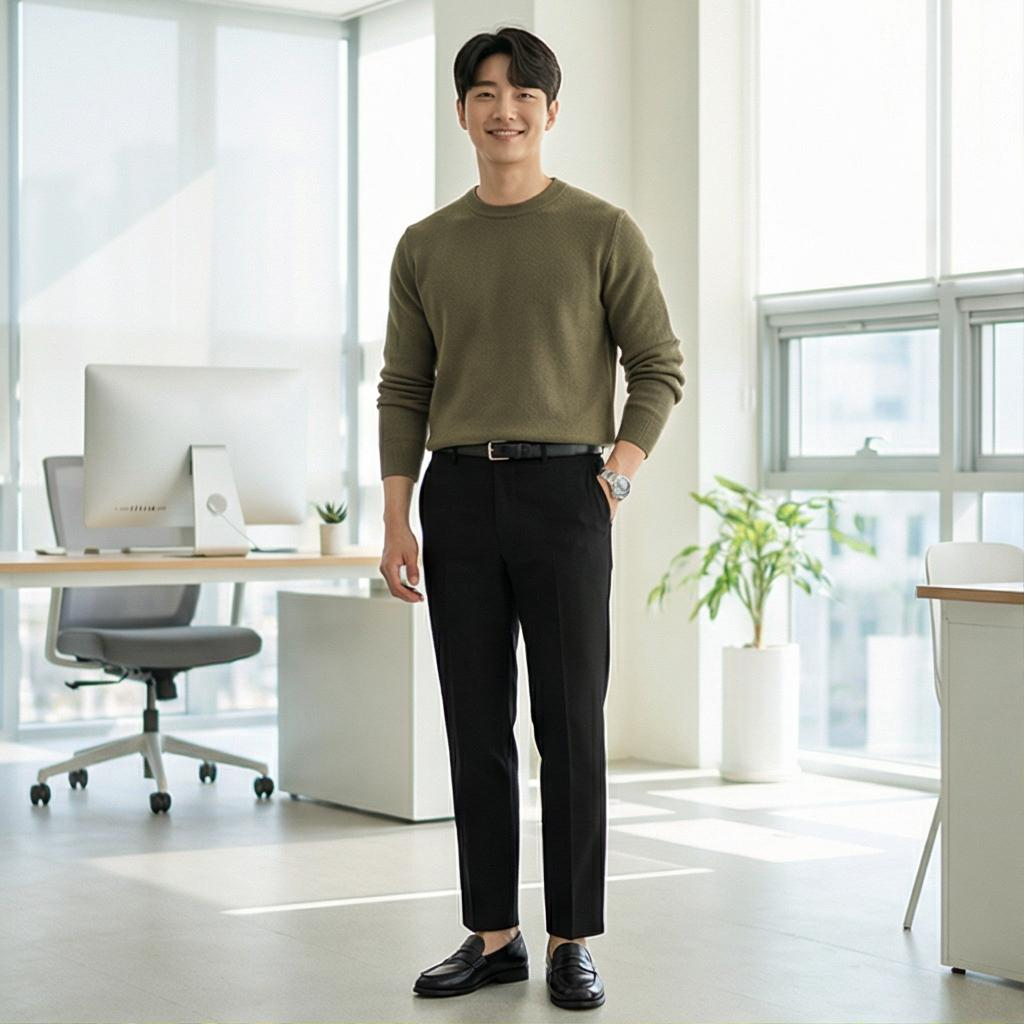

{'purpose': '데일리', 'desired_style': '캐주얼', 'budget': 160000, 'change_scope': '전체 변경', 'height_cm': None, 'weight_kg': None, 'chest_cm': None, 'waist_cm': None, 'hip_cm': None, 'season': '사계절', 'silhouette_goal': '반영 안 함', 'dress_code': '자동', 'activity_level': '보통', 'preferred_colors': [], 'avoided_colors': [], 'avoided_materials': [], 'excluded_item_types': [], 'temperature_c': None, 'feels_like_c': None, 'humidity': None, 'precipitation_probability': None, 'wind_mps': None, 'uv_index': None, 'owned_items': [], 'gender': ''}


In [30]:
profile = UserProfile(
    purpose='데일리',
    desired_style='캐주얼',
    budget=160_000,
    change_scope='전체 변경',  # 현재 유지 / 상의만 변경 / 하의만 변경 / 전체 변경
    height_cm=None,
    weight_kg=None,
    season='사계절',
)
USE_FASHN_PARSER = True
USE_FASHION_SIGLIP = True
USE_VTON = False
CURRENT_OUTFIT_KEEP_THRESHOLD = 95.0  # 이 점수 이상이고 분석이 신뢰 가능하면 교체 추천 생략

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(
        f'입력 이미지가 없습니다: {IMAGE_PATH}\n'
        '0번 셀의 IMAGE_PATH_INPUT을 본인의 전신사진 경로로 변경하세요.'
    )
if not (DATA_DIR / 'products.csv').is_file():
    raise FileNotFoundError(f'상품 파일이 없습니다: {DATA_DIR / "products.csv"}')
if not RULES_PATH.is_file():
    raise FileNotFoundError(f'규칙 파일이 없습니다: {RULES_PATH}')
display(Image.open(IMAGE_PATH).convert('RGB'))
print(profile.to_dict())

## 2. 입력 사진 품질 검사

In [31]:
# 이 셀을 다시 실행할 때 이전 MediaPipe 인스턴스를 먼저 정리합니다.
if 'pose_analyzer' in globals():
    pose_analyzer.close()
pose_analyzer = PoseAnalyzer(model_complexity=1)
quality_checker = QualityChecker(pose_analyzer)
# 포즈는 여기서 한 번만 계산하고 이후 단계에서 재사용합니다.
pose_result = pose_analyzer.analyze(IMAGE_PATH)
input_quality = quality_checker.check_input(IMAGE_PATH, pose=pose_result)
print(json.dumps(input_quality, ensure_ascii=False, indent=2))
if not input_quality['passed']:
    raise ValueError('전신사진 품질 기준을 통과하지 못했습니다. issues 항목을 확인하세요.')

{
  "passed": true,
  "resolution": [
    1024,
    1024
  ],
  "sharpness": 108.36,
  "full_body_score": 0.9898,
  "issues": [
    "어깨·골반 값은 관절 간격 기반 상대 추정치이며 실제 신체 치수가 아닙니다."
  ]
}


I0000 00:00:1787599222.695085  153423 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1787599222.749972  176319 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787599222.753385  176325 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 3. MediaPipe 체형·자세 분석

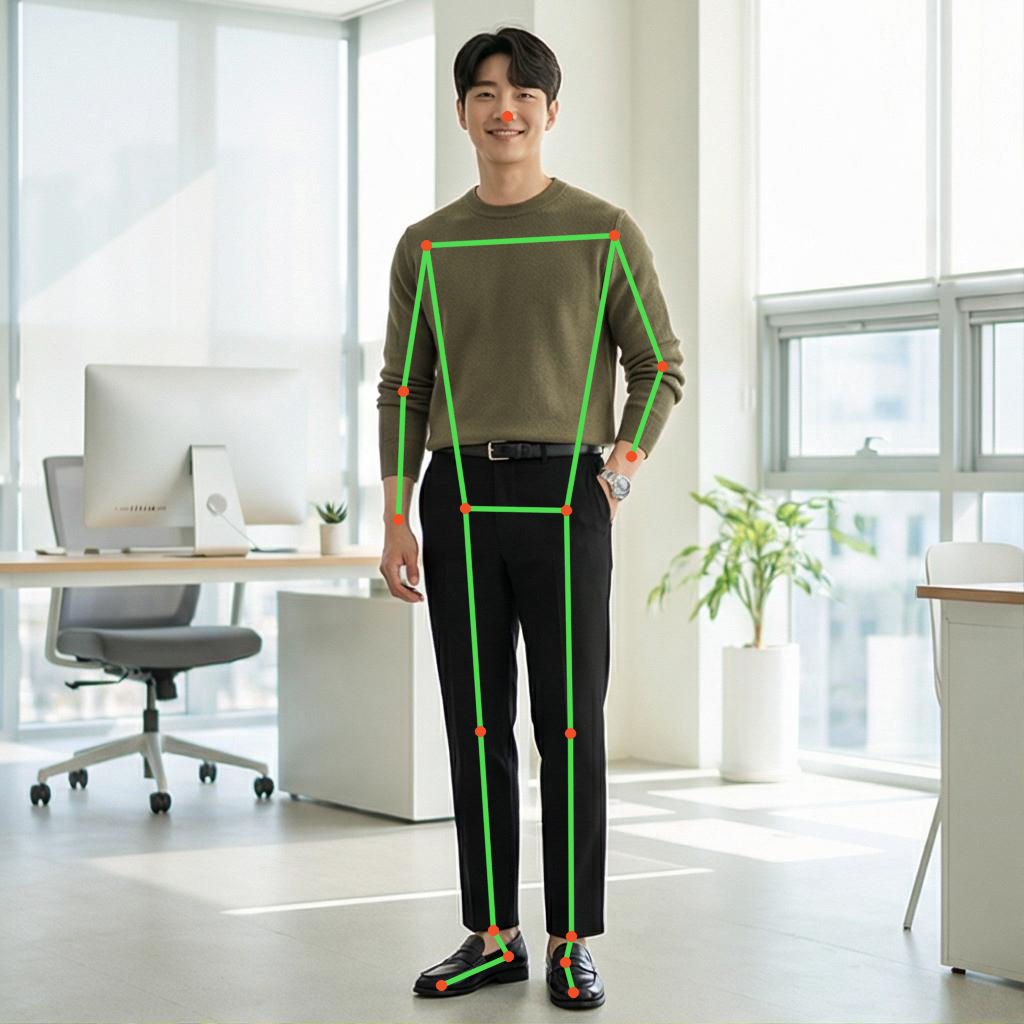

{
  "valid": true,
  "full_body_score": 0.9898,
  "body_shape": "역삼각체형",
  "shoulder_hip_ratio": 1.4732,
  "upper_lower_ratio": 0.6176,
  "leg_ratio": 0.6182,
  "posture": "정면에 가까움",
  "body_shape_confidence": 0.8937,
  "warnings": [
    "어깨·골반 값은 관절 간격 기반 상대 추정치이며 실제 신체 치수가 아닙니다."
  ]
}


In [32]:
if not pose_result.valid:
    raise ValueError('유효한 전신 포즈를 찾지 못했습니다.')
display(pose_analyzer.draw_landmarks(IMAGE_PATH, analysis=pose_result))
print(json.dumps({k: v for k, v in pose_result.to_dict().items() if k != 'landmarks'}, ensure_ascii=False, indent=2))

## 4. 의류 분리와 현재 착장 분석

FASHN으로 픽셀 마스크를 만들고 MediaPipe로 기장을 계산합니다. FashionSigLIP 후보군은 DeepFashion-MultiModal의 소재·패턴·네크라인 라벨에 맞춰 구성했습니다.

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

FashionSigLIP 실행 장치: cpu
학습된 속성 헤드: 사용


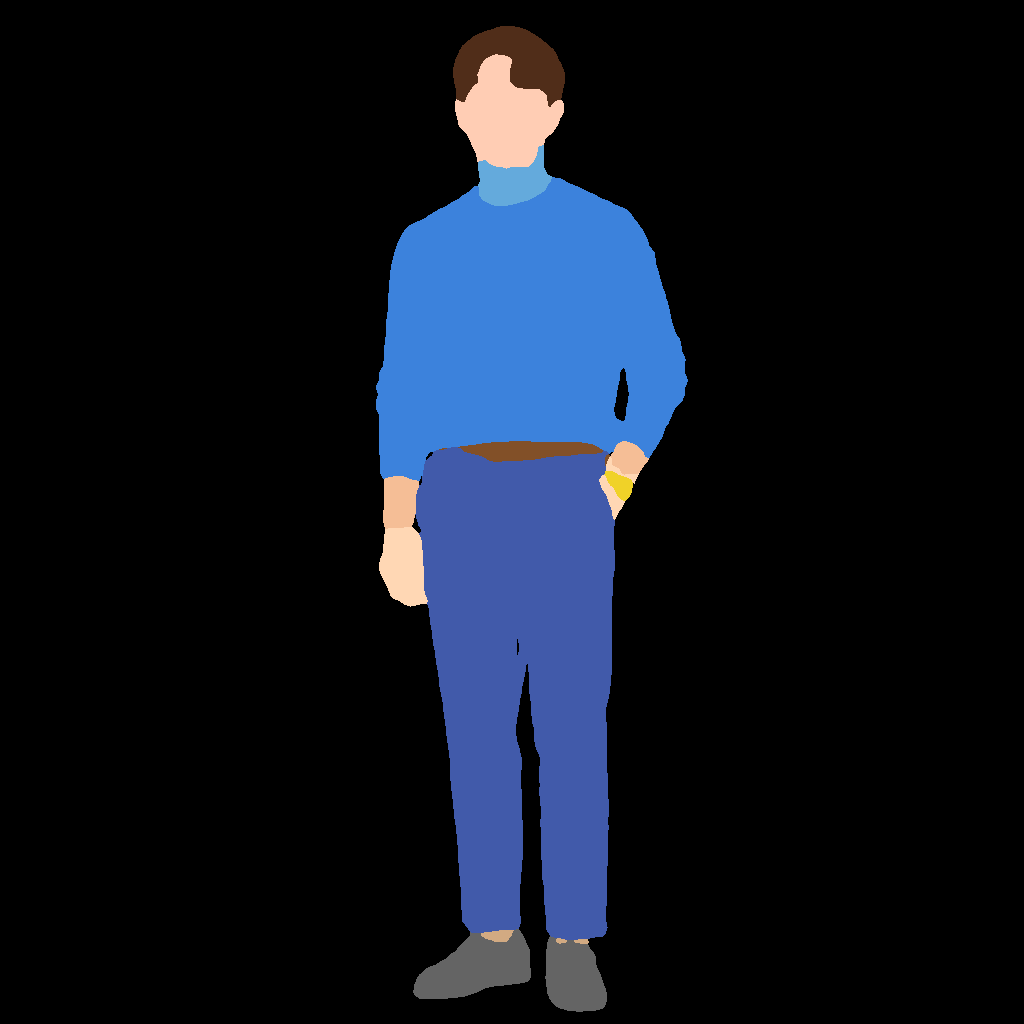

{
  "parser_backend": "fashn-human-parser",
  "upper_color": "브라운",
  "lower_color": "블랙",
  "color_harmony": "안정적인 무채색 조합",
  "detected_items": [
    "face",
    "hair",
    "top",
    "pants",
    "belt",
    "arms",
    "hands",
    "legs",
    "feet",
    "torso",
    "jewelry"
  ],
  "style": "미니멀",
  "upper_type": "니트",
  "lower_type": "팬츠",
  "lower_subtype": "슬랙스",
  "pant_leg_shape": "스트레이트",
  "pant_length": "풀렝스",
  "sleeve_length": "긴팔",
  "visible_sleeve_length": "긴팔",
  "sleeve_state": "정상",
  "layering_state": "레이어드 가능성",
  "upper_items": [
    "안쪽 상의(종류 불확실)",
    "니트"
  ],
  "inner_category": "종류 불확실",
  "outer_category": "니트",
  "wear_state_confidence": {
    "sleeve_state": 0.942,
    "layering_state": 0.956
  },
  "upper_length": "크롭 기장",
  "bottom_length": "긴바지",
  "fit": "여유핏·오버핏 추정",
  "lower_fit": "와이드핏 추정",
  "neckline": "라운드넥",
  "pattern": "무지",
  "material": "니트",
  "lower_pattern": "무지",
  "lower_material": "코튼 추정",
  "sleeve_shape": "기본 소매",
  "collar": "분

In [33]:
clothing_parser = ClothingParser(use_fashn=USE_FASHN_PARSER)
# 학습된 의류 속성 헤드(Fashionpedia+Fashion200K 학습)가 있으면 FashionSigLIP 특징 위에
# 얹어 옷 종류·소매·기장·핏 등의 인식에 사용하고, 없으면 zero-shot 분류만 사용한다.
fashion_classifier = FashionClassifier(
    enabled=USE_FASHION_SIGLIP,
    attribute_checkpoint=ATTRIBUTE_HEADS_PATH if USE_FASHION_SIGLIP and ATTRIBUTE_HEADS_PATH.is_file() else None,
    layering_checkpoint=LAYERING_HEADS_PATH if USE_FASHION_SIGLIP and LAYERING_HEADS_PATH.is_file() else None,
)
print('FashionSigLIP 실행 장치:', fashion_classifier.device)
print('학습된 속성 헤드:', '사용' if fashion_classifier.trained_attributes_enabled else '없음 (zero-shot만 사용)')
print('학습된 레이어드 헤드:', '사용' if fashion_classifier.trained_layering_enabled else '없음 (기존 fallback 사용)')
outfit_analyzer = OutfitAnalyzer(clothing_parser, fashion_classifier)
outfit_result, parsed = outfit_analyzer.analyze(IMAGE_PATH, pose_result)
if USE_FASHN_PARSER and parsed['backend'] != 'fashn-human-parser':
    raise RuntimeError('FASHN 파서가 요청되었지만 실제 모델이 사용되지 않았습니다.')
segmentation_preview = clothing_parser.colorize(parsed['segmentation'])
segmentation_path = OUTPUT_DIR / 'fashn_segmentation.jpg'
segmentation_preview.save(segmentation_path)
display(segmentation_preview)
print(json.dumps(outfit_result.to_dict(), ensure_ascii=False, indent=2))
print('의류 분할 결과:', segmentation_path)
if not outfit_result.input_valid:
    raise RuntimeError(
        f'INPUT ERROR [{outfit_result.input_error_code}]\n'
        f'{outfit_result.input_error_message}'
    )

## 5. 코디 후보 탐색과 순위 결정

In [ ]:
from IPython.display import HTML

catalog = ProductCatalog(DATA_DIR / 'products.csv')
# 추천 엔진은 FASHION_RULES_MASTER.md의 R-* 규칙을 직접 읽는다.
recommender = RecommendationEngine(RULES_PATH, catalog)
print('활성 규칙:', len(recommender.active_rule_ids), '/ 문서화된 규칙:', len(recommender.documented_rule_ids))
if recommender.unsupported_rule_ids:
    print('미지원 규칙:', ', '.join(recommender.unsupported_rule_ids))

# 아래 점수는 추천 상품 점수가 아니라, 업로드한 사진 속 현재 착장 자체의 평가다.
current_outfit_evaluation = recommender.evaluate_current_outfit(
    profile, pose_result, outfit_result, keep_threshold=CURRENT_OUTFIT_KEEP_THRESHOLD,
)
score_color = '#16803c' if current_outfit_evaluation.should_keep else ('#b45309' if current_outfit_evaluation.reliable else '#64748b')
display(HTML(f'''
<div style="border:3px solid {score_color}; border-radius:18px; padding:22px 26px; margin:18px 0; background:#ffffff; box-shadow:0 8px 24px rgba(15,23,42,.10);">
  <div style="font-size:14px; font-weight:800; letter-spacing:.12em; color:{score_color};">CURRENT OUTFIT SCORE</div>
  <div style="font-size:52px; line-height:1.05; font-weight:900; color:#111827; margin-top:8px;">
    {current_outfit_evaluation.total_score:.1f}<span style="font-size:20px; color:#64748b;"> / 100</span>
  </div>
  <div style="font-size:21px; font-weight:800; color:{score_color}; margin-top:10px;">{current_outfit_evaluation.verdict}</div>
  <div style="font-size:13px; color:#64748b; margin-top:10px;">
    교체 생략 기준 {CURRENT_OUTFIT_KEEP_THRESHOLD:.0f}점 · 평가 범위 {current_outfit_evaluation.score_coverage:.0f}% · 분석 신뢰도 {current_outfit_evaluation.analysis_confidence:.2f}
  </div>
</div>
'''))
for name, score in current_outfit_evaluation.score_breakdown.items():
    print(f'  - {name}: {score:.1f}')
for reason in current_outfit_evaluation.reasons:
    print('  · 현재 착장 평가:', reason)

recommendations = recommender.recommend(
    profile, pose_result, outfit_result, top_k=3,
    current_outfit_keep_threshold=CURRENT_OUTFIT_KEEP_THRESHOLD,
)
for recommendation in recommendations:
    label = '현재 코디 유지' if not recommendation.products else f'추천 #{recommendation.rank} 총점'
    print(f'\n{label}: {recommendation.total_score:.1f}')
    for product in recommendation.products:
        print(f'  - {product.name} / {product.color} / {product.price:,}원')
    for reason in recommendation.reasons:
        print('  ·', reason)
    for tip in recommendation.styling_tips:
        print('  💡', tip)
    print('  · 적용 규칙:', ', '.join(recommendation.applied_rules) or '없음')
    print(f'  · 점수 계산 범위: {recommendation.score_coverage:.0f}%')

## 6. 결과 이미지 생성

In [ ]:
# USE_VTON=True면 CatVTON 디퓨전으로 실제 착장 합성을, False면 추천 보드를 만든다.
# 합성에는 4단계에서 만든 FASHN 마스크(경계)와 세그멘테이션(얼굴·손 보호)을 그대로 사용한다.
if USE_VTON:
    from catvton_tryon import CatVTONTryOn

    tryon = CatVTONTryOn()
else:
    tryon = VirtualTryOnAdapter(enabled=False)
preview_path = tryon.generate(
    person_image=IMAGE_PATH,
    recommendation=recommendations[0],
    output_path=OUTPUT_DIR / 'recommendation_preview.jpg',
    context={
        'upper_mask': parsed.get('upper_mask'),
        'lower_mask': parsed.get('lower_mask'),
        'upper_style_mask': parsed.get('upper_style_mask'),
        'lower_style_mask': parsed.get('lower_style_mask'),
        'segmentation': parsed.get('segmentation'),
        # 합성 신뢰도 점검(레퍼런스 해상도·기장 차이)에 필요한 재료
        'outfit': outfit_result,
        'classifier': fashion_classifier,
    },
)
display(Image.open(preview_path))
print('결과 저장 위치:', preview_path)
# 경고가 있으면 결과를 그대로 믿지 말 것. 원인과 대처는 README '합성 품질' 참고.
for warning in getattr(tryon, 'last_warnings', []):
    print('⚠️', warning)

## 7. 선택적 피드백 저장과 최종 요약

In [ ]:
SAVE_EXAMPLE_FEEDBACK = False
feedback_store = FeedbackStore(OUTPUT_DIR / 'feedback.jsonl')
if SAVE_EXAMPLE_FEEDBACK:
    feedback_store.append(recommendation_rank=1, action='마음에 들어요', note='테스트')

summary = {
    'input_quality_passed': input_quality['passed'],
    'body_shape': pose_result.body_shape,
    'parser_backend': outfit_result.parser_backend,
    'garments': {
        'upper_type': outfit_result.upper_type,
        'lower_type': outfit_result.lower_type,
        'sleeve_length': outfit_result.sleeve_length,
        'visible_sleeve_length': outfit_result.visible_sleeve_length,
        'sleeve_state': outfit_result.sleeve_state,
        'layering_state': outfit_result.layering_state,
        'upper_items': outfit_result.upper_items,
        'inner_category': outfit_result.inner_category,
        'outer_category': outfit_result.outer_category,
        'upper_length': outfit_result.upper_length,
        'bottom_length': outfit_result.bottom_length,
        'fit': outfit_result.fit,
        'neckline': outfit_result.neckline,
        'pattern': outfit_result.pattern,
        'material': outfit_result.material,
    },
    'current_outfit': current_outfit_evaluation.to_dict(),
    'best_score': recommendations[0].total_score,
    'score_coverage': recommendations[0].score_coverage,
    'preview_path': str(preview_path),
}
print(json.dumps(summary, ensure_ascii=False, indent=2))
pose_analyzer.close()